In [9]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))

from src.ring_attractor import RingAttractor, SpikeProcessor
from src.ring_attractor.plotting import polar_snapshot

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

In [10]:
N = 100               # Number of neurons
J0 = -2.0             # Global inhibition
J1 = 4.0              # Local excitation
STEEPNESS = 4.0       # f-I curve steepness
ALPHA = 0.01          # Leak rate (= dt / tau)
SIGMA = 0.0           # Noise off for clean demos

T_CUE = 2000          # Steps with external cue
T_FREE = 5500         # Steps of autonomous dynamics
T_TOTAL = T_CUE + T_FREE

CUE_AMPLITUDE = 3.0   # Peak of the Gaussian cue
THETA_TARGET = np.pi / 3  # 60°

SEED = 42

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

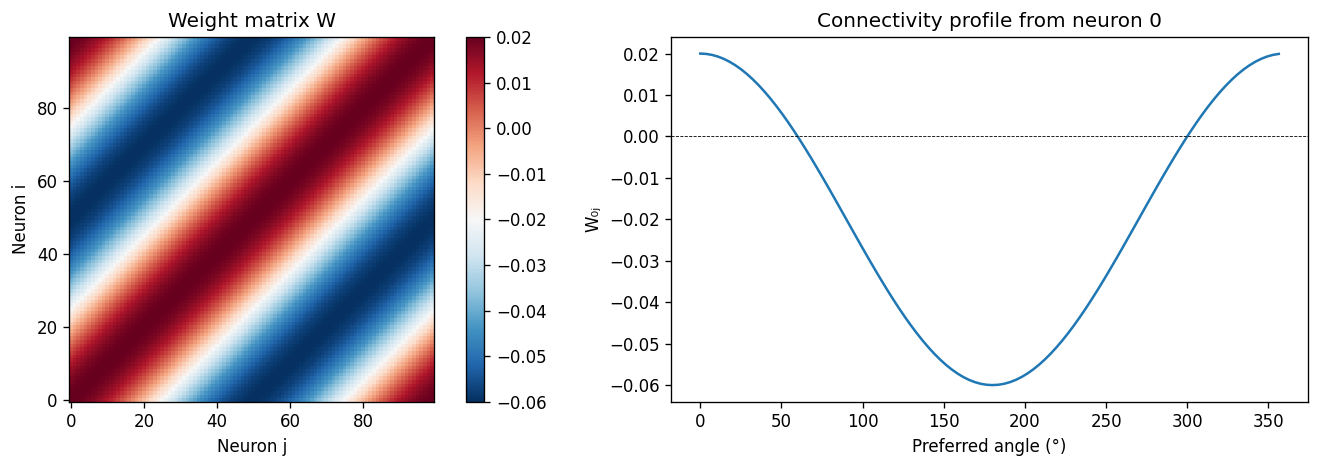

In [11]:
# ## 1. Create the network and inspect initial state
#
# The ring attractor is a network of 100 neurons arranged on a circle.
# Each neuron has a preferred angle θ_i = 2πi/N.  Connectivity follows
# a cosine kernel: W_ij = (J0 + J1 cos(θ_i − θ_j)) / N.

ring = RingAttractor(N=N, J0=J0, J1=J1, steepness=STEEPNESS, alpha=ALPHA, sigma=SIGMA)

# Show the weight matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
im = ax1.imshow(ring.weights, cmap="RdBu_r", origin="lower")
ax1.set_xlabel("Neuron j")
ax1.set_ylabel("Neuron i")
ax1.set_title("Weight matrix W")
plt.colorbar(im, ax=ax1)

# Weights from neuron 0 to all others (the connectivity profile)
ax2.plot(np.degrees(ring.angles), ring.weights[0], color="tab:blue")
ax2.set_xlabel("Preferred angle (°)")
ax2.set_ylabel("W₀ⱼ")
ax2.set_title("Connectivity profile from neuron 0")
ax2.axhline(0, color="k", lw=0.5, ls="--")
plt.tight_layout()
plt.show()

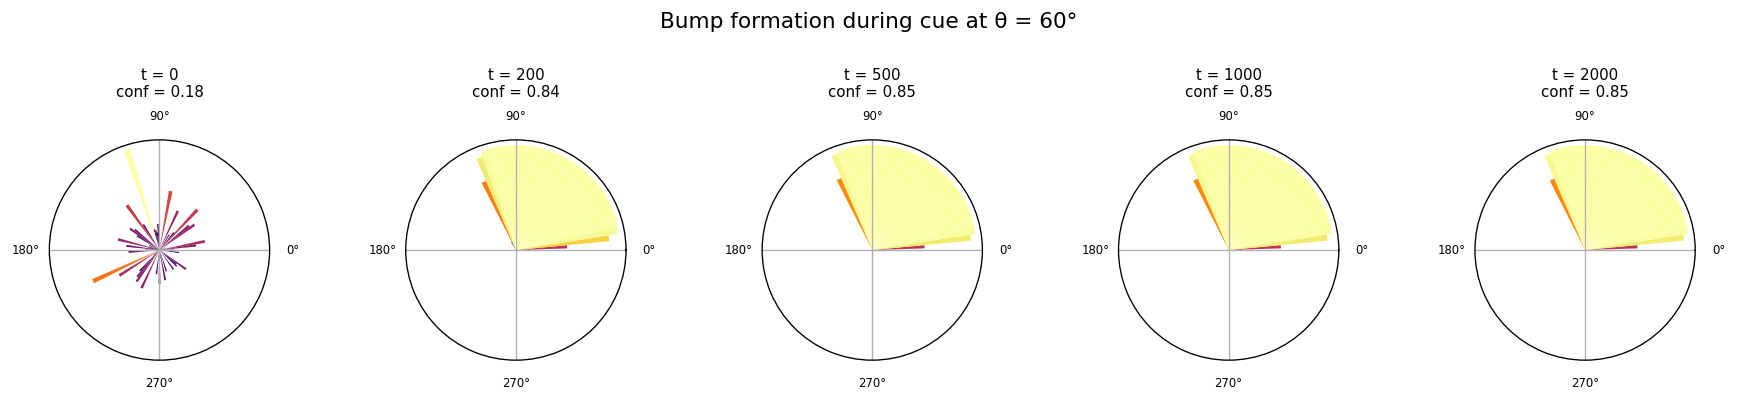

In [12]:
# ## 2. Apply a cue and form a bump
#
# We inject a localised Gaussian cue at θ = 60° for a few hundred steps
# and watch the bump form.

snap_steps = [0, 200, 500, 1000, 2000]
res_cue = ring.simulate(T=max(snap_steps) + 1, cue_angles=[THETA_TARGET], cue_duration=max(snap_steps) + 1, seed=SEED)

fig, axes = plt.subplots(1, len(snap_steps), figsize=(15, 3), subplot_kw={"projection": "polar"})
fig.suptitle(f"Bump formation during cue at θ = {np.degrees(THETA_TARGET):.0f}°", fontsize=13, y=1.05)
for ax, t in zip(axes, snap_steps):
    polar_snapshot(ax, res_cue.rates[t], res_cue.angles, title=f"t = {t}\nconf = {res_cue.confidence[t]:.2f}")

plt.tight_layout()
plt.show()